In [1]:
# --- Setup & Imports ---
import os
import sys

# Clone repository
REPO_URL = "https://github.com/ThaiLearnCoding/Coco_classification.git"
REPO_NAME = REPO_URL.split('/')[-1].replace('.git', '')

if not os.path.exists(REPO_NAME):
    print(f"Cloning repository: {REPO_URL}")
    !git clone {REPO_URL}

# Move into the repository
if os.path.exists(REPO_NAME):
    os.chdir(REPO_NAME)

# Install dependencies
print("Installing requirements...")
!pip install -q -r requirements.txt
!pip install -q gdown # Install gdown for Google Drive downloads

Cloning repository: https://github.com/ThaiLearnCoding/Coco_classification.git
Cloning into 'Coco_classification'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 33 (delta 11), reused 29 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 85.09 KiB | 1.25 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Installing requirements...
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00


In [2]:
# --- Add utilities ---

# Standard imports
import json
import yaml
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from zipfile import ZipFile
from collections import Counter
import numpy as np
from torch.utils.data import DataLoader, Subset

# Add src to path so we can import modules
# Assuming notebook is in 'notebooks/' and src is in '../src/'
if os.getcwd().endswith('notebooks'):
    sys.path.append('../src')
    os.chdir('..') # Change CWD to project root for data/config access
else:
    sys.path.append('./src')

# Import project modules
try:
    from models import CLIPFewShotModel
    from data_utils import get_dataloaders, CocoMultimodalDataset
    from engine import evaluate_zero_shot, train_few_shot
    from visualization import CLIPGradCAM, display_sample, plot_sample_predictions, plot_confusion_matrix, plot_grad_cam
except ImportError as e:
    print(f"Error importing modules: {e}")
    print("Make sure you are in the project root and 'src' directory exists.")

print(f"Current Working Directory: {os.getcwd()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Current Working Directory: /content/Coco_classification
Device: cuda


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1VtF-EVa53F6HezvCUWz6qQMueZOoRDPR
From (redirected): https://drive.google.com/uc?id=1VtF-EVa53F6HezvCUWz6qQMueZOoRDPR&confirm=t&uuid=881108fe-40ba-4911-9512-39f166b1b40f
To: /content/Coco_classification/data/coco_multimodal_subset.zip
100% 382M/382M [00:05<00:00, 73.7MB/s]


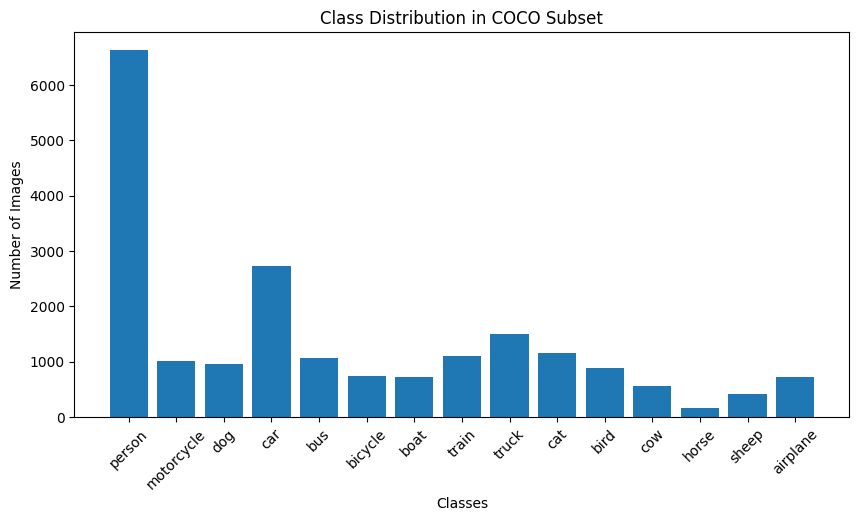

In [3]:
# --- Exploratory Data Analysis (EDA) ---

if not os.path.exists('data'):
    os.makedirs('data')

# Extract file ID from the Google Drive sharing link
zip_file_id = '1VtF-EVa53F6HezvCUWz6qQMueZOoRDPR'
zip_path_colab = 'data/coco_multimodal_subset.zip'

# Download the file using gdown if it doesn't already exist
if not os.path.exists(zip_path_colab):
    print(f"Downloading data from Google Drive (ID: {zip_file_id})...")
    !gdown --id {zip_file_id} -O {zip_path_colab}
else:
    print(f"Zip file already exists at {zip_path_colab}.")

ZIP_PATH = zip_path_colab # Ensure ZIP_PATH is correctly set for subsequent use

# Read metadata to visualize Class Distribution
if os.path.exists(ZIP_PATH):
    with ZipFile(ZIP_PATH, 'r') as z:
        if 'metadata.json' in z.namelist():
            metadata = json.loads(z.read('metadata.json'))

            # Count labels
            all_labels = [label for item in metadata for label in item['labels']]
            label_counts = Counter(all_labels)

            # Plot
            plt.figure(figsize=(10, 5))
            plt.bar(label_counts.keys(), label_counts.values())
            plt.title('Class Distribution in COCO Subset')
            plt.xlabel('Classes')
            plt.ylabel('Number of Images')
            plt.xticks(rotation=45)
            plt.show()
        else:
            print("metadata.json not found in zip.")
else:
    print("Cannot perform EDA: Zip file not found after download attempt.")

In [4]:
# --- Configuration & Model Initialization ---

# Load Config
CONFIG_PATH = 'configs/config.yaml'

with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

print("Configuration loaded:")
# print(yaml.dump(config, sort_keys=False))

device = config['model']['device'] if torch.cuda.is_available() else 'cpu'

# Initialize Model
# Uses CLIP backbone (frozen) + Linear Classifier
model = CLIPFewShotModel(config['model']['name'], len(config['data']['classes']), device)
print(f"Model initialized: {config['model']['name']}")

Configuration loaded:


100%|███████████████████████████████████████| 891M/891M [00:31<00:00, 29.9MiB/s]


Model initialized: ViT-L/14@336px


Full Train size: 8295
Test size: 2074


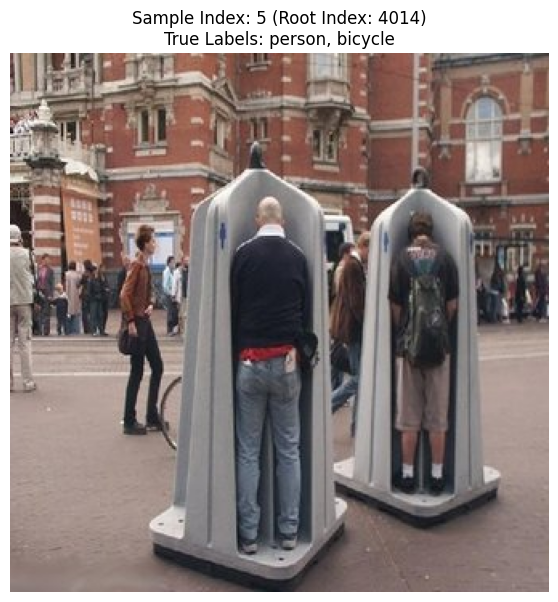

In [5]:
# --- Data Loading ---

# Get DataLoaders (Full Train / Test split from config)
# Note: full_train_loader contains 80% of data, used for sampling k-shots later
full_train_loader, test_loader = get_dataloaders(config, model.preprocess)

print(f"Full Train size: {len(full_train_loader.dataset)}")
print(f"Test size: {len(test_loader.dataset)}")

display_sample(full_train_loader.dataset, 5, config)

In [6]:
# --- Zero-Shot Evaluation ---
# Evaluate CLIP's zero-shot capability before any training

print("Running Zero-Shot Evaluation...")
zero_shot_report = evaluate_zero_shot(model, test_loader, config['data']['classes'], device)
print("\n=== Zero-Shot Classification Report ===")
print(zero_shot_report)

Running Zero-Shot Evaluation...


Zero-shot Eval: 100%|██████████| 65/65 [03:27<00:00,  3.19s/it]


=== Zero-Shot Classification Report ===
              precision    recall  f1-score   support

      person       0.95      0.45      0.61      1345
     bicycle       0.23      0.74      0.36        31
         car       0.46      0.46      0.46       102
  motorcycle       0.13      0.92      0.23        25
    airplane       0.61      0.98      0.75        95
         bus       0.24      0.79      0.37        68
       train       0.45      0.99      0.62       112
       truck       0.41      0.57      0.48        87
        bird       0.83      0.87      0.85       138
         dog       0.41      0.97      0.58        71

    accuracy                           0.58      2074
   macro avg       0.47      0.78      0.53      2074
weighted avg       0.79      0.58      0.61      2074



In [7]:
# --- Few-Shot Sampling & Training Setup ---

def create_few_shot_subset(dataset, k=16, classes=None):
    """
    Selects k samples per class from the dataset.
    """
    if classes is None:
        return dataset

    # Access the underlying dataset if it's a Subset
    if isinstance(dataset, Subset):
        root_dataset = dataset.dataset
        subset_indices = dataset.indices
    else:
        root_dataset = dataset
        subset_indices = range(len(dataset))

    class_indices = {cls: [] for cls in classes}

    # Iterate through the available indices in the training subset
    for idx in subset_indices:
        # Access metadata directly from root dataset
        meta = root_dataset.filtered_data[idx]

        # Find which class this sample belongs to (first matching target class)
        label_name = [l for l in meta['labels'] if l in classes]
        if label_name:
            label_name = label_name[0]
            if len(class_indices[label_name]) < k:
                class_indices[label_name].append(idx) # Keep original index

    # Collect all selected indices
    final_indices = []
    for cls, indices in class_indices.items():
        if len(indices) < k:
            print(f"Warning: Class '{cls}' has only {len(indices)} samples, requested {k}.")
        final_indices.extend(indices)

    return Subset(root_dataset, final_indices)

def reset_model(config):
    """Re-initialize the model to reset weights for fair comparison."""
    return CLIPFewShotModel(config['model']['name'], len(config['data']['classes']), config['model']['device'])

# Add this utility to get accuracy
from sklearn.metrics import accuracy_score

def evaluate_accuracy(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    plot_sample_predictions(images, labels, preds, config['data']['classes'], n=5)
    plot_confusion_matrix(all_labels, all_preds, config['data']['classes'], title="Test Set Confusion Matrix")

    return accuracy_score(all_labels, all_preds)

print("Evaluation utilities ready.")

Evaluation utilities ready.


In [8]:
# --- Final Evaluation (after Few-Shot) ---

print("Running Evaluation after Few-Shot Training...")
final_report = evaluate_zero_shot(model, test_loader, config['data']['classes'], device)
print("\n=== Few-Shot Classification Report ===")
print(final_report)

Running Evaluation after Few-Shot Training...


Zero-shot Eval: 100%|██████████| 65/65 [03:25<00:00,  3.16s/it]


=== Few-Shot Classification Report ===
              precision    recall  f1-score   support

      person       0.95      0.45      0.61      1345
     bicycle       0.23      0.74      0.36        31
         car       0.46      0.46      0.46       102
  motorcycle       0.13      0.92      0.23        25
    airplane       0.61      0.98      0.75        95
         bus       0.24      0.79      0.37        68
       train       0.45      0.99      0.62       112
       truck       0.41      0.57      0.48        87
        bird       0.83      0.87      0.85       138
         dog       0.41      0.97      0.58        71

    accuracy                           0.58      2074
   macro avg       0.47      0.78      0.53      2074
weighted avg       0.79      0.58      0.61      2074



Evaluating Zero-shot Baseline...


Zero-shot Eval: 100%|██████████| 65/65 [03:25<00:00,  3.15s/it]



--- Starting Comparison Experiment: K=[1, 5, 8, 16] ---

Training with K=1 shots per class...
Epoch 1/20, Loss: 2.3106
Epoch 2/20, Loss: 2.2973
Epoch 3/20, Loss: 2.2839
Epoch 4/20, Loss: 2.2706
Epoch 5/20, Loss: 2.2574
Epoch 6/20, Loss: 2.2441
Epoch 7/20, Loss: 2.2309
Epoch 8/20, Loss: 2.2177
Epoch 9/20, Loss: 2.2045
Epoch 10/20, Loss: 2.1914
Epoch 11/20, Loss: 2.1783
Epoch 12/20, Loss: 2.1652
Epoch 13/20, Loss: 2.1521
Epoch 14/20, Loss: 2.1391
Epoch 15/20, Loss: 2.1261
Epoch 16/20, Loss: 2.1131
Epoch 17/20, Loss: 2.1002
Epoch 18/20, Loss: 2.0873
Epoch 19/20, Loss: 2.0744
Epoch 20/20, Loss: 2.0615


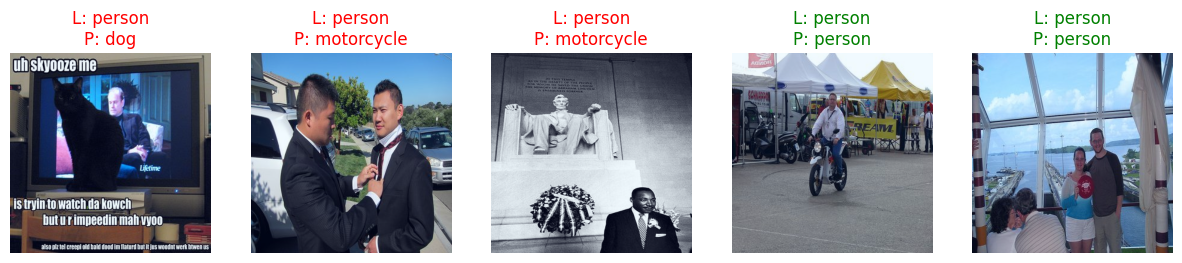

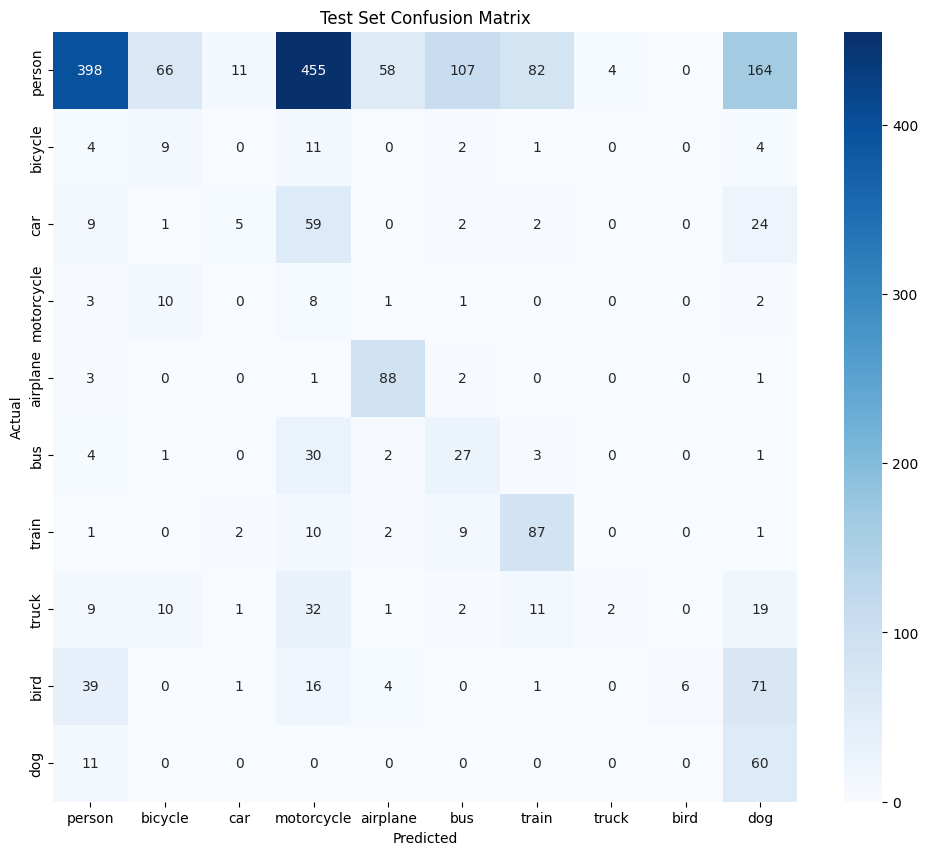

--> K=1 Accuracy: 0.3327

Training with K=5 shots per class...
Epoch 1/20, Loss: 2.3027
Epoch 2/20, Loss: 2.2897
Epoch 3/20, Loss: 2.2756
Epoch 4/20, Loss: 2.2645
Epoch 5/20, Loss: 2.2520
Epoch 6/20, Loss: 2.2394
Epoch 7/20, Loss: 2.2310
Epoch 8/20, Loss: 2.2196
Epoch 9/20, Loss: 2.2085
Epoch 10/20, Loss: 2.1999
Epoch 11/20, Loss: 2.1854
Epoch 12/20, Loss: 2.1750
Epoch 13/20, Loss: 2.1642
Epoch 14/20, Loss: 2.1551
Epoch 15/20, Loss: 2.1402
Epoch 16/20, Loss: 2.1310
Epoch 17/20, Loss: 2.1274
Epoch 18/20, Loss: 2.1112
Epoch 19/20, Loss: 2.0977
Epoch 20/20, Loss: 2.0898


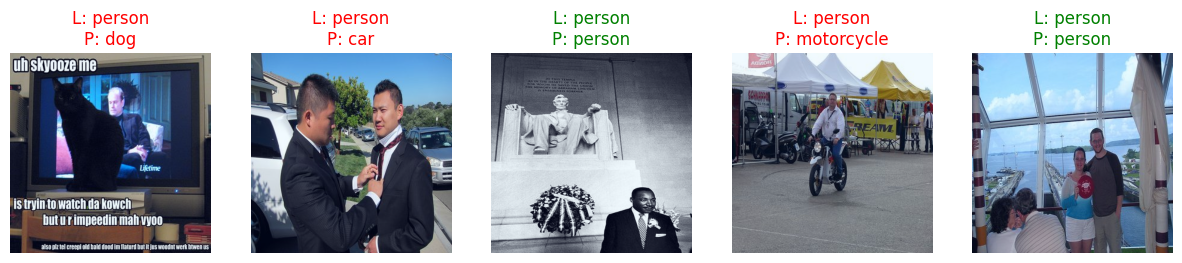

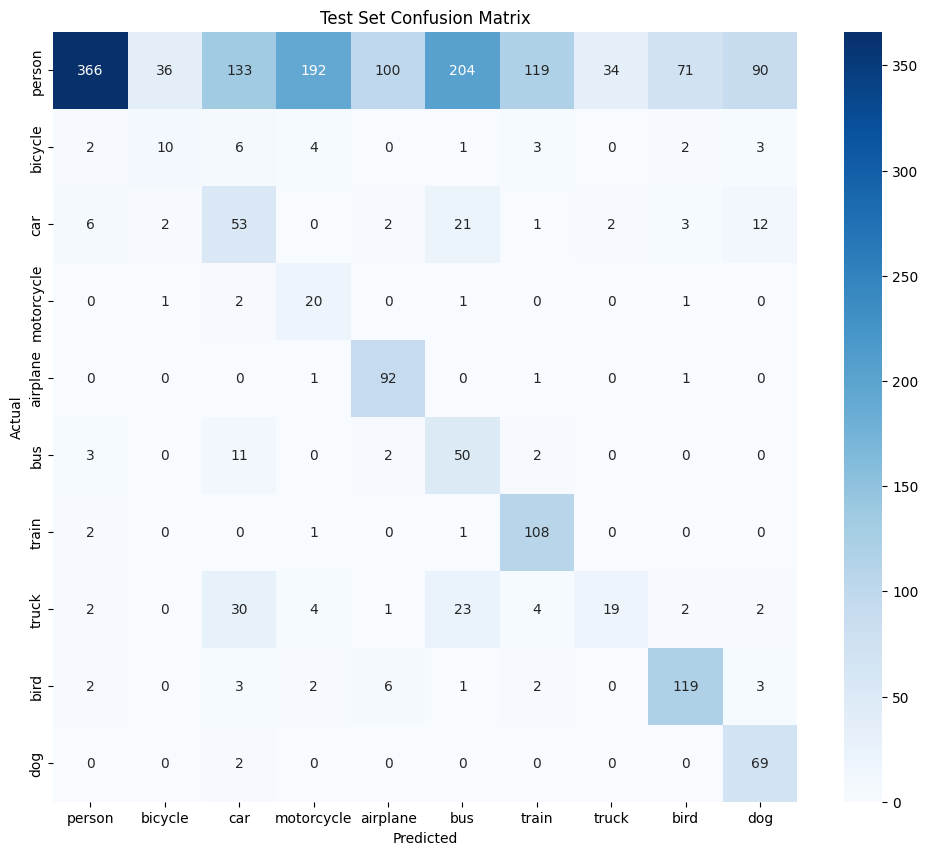

--> K=5 Accuracy: 0.4368

Training with K=8 shots per class...
Epoch 1/20, Loss: 2.3038
Epoch 2/20, Loss: 2.2886
Epoch 3/20, Loss: 2.2739
Epoch 4/20, Loss: 2.2580
Epoch 5/20, Loss: 2.2425
Epoch 6/20, Loss: 2.2309
Epoch 7/20, Loss: 2.2170
Epoch 8/20, Loss: 2.2027
Epoch 9/20, Loss: 2.1911
Epoch 10/20, Loss: 2.1772
Epoch 11/20, Loss: 2.1649
Epoch 12/20, Loss: 2.1477
Epoch 13/20, Loss: 2.1333
Epoch 14/20, Loss: 2.1230
Epoch 15/20, Loss: 2.1072
Epoch 16/20, Loss: 2.0977
Epoch 17/20, Loss: 2.0830
Epoch 18/20, Loss: 2.0617
Epoch 19/20, Loss: 2.0534
Epoch 20/20, Loss: 2.0463


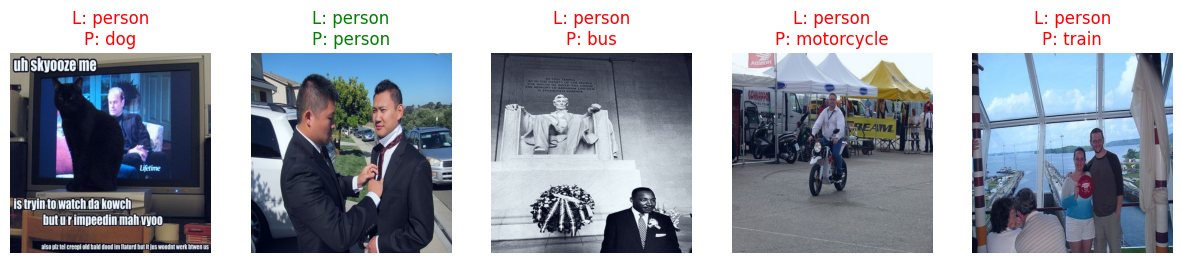

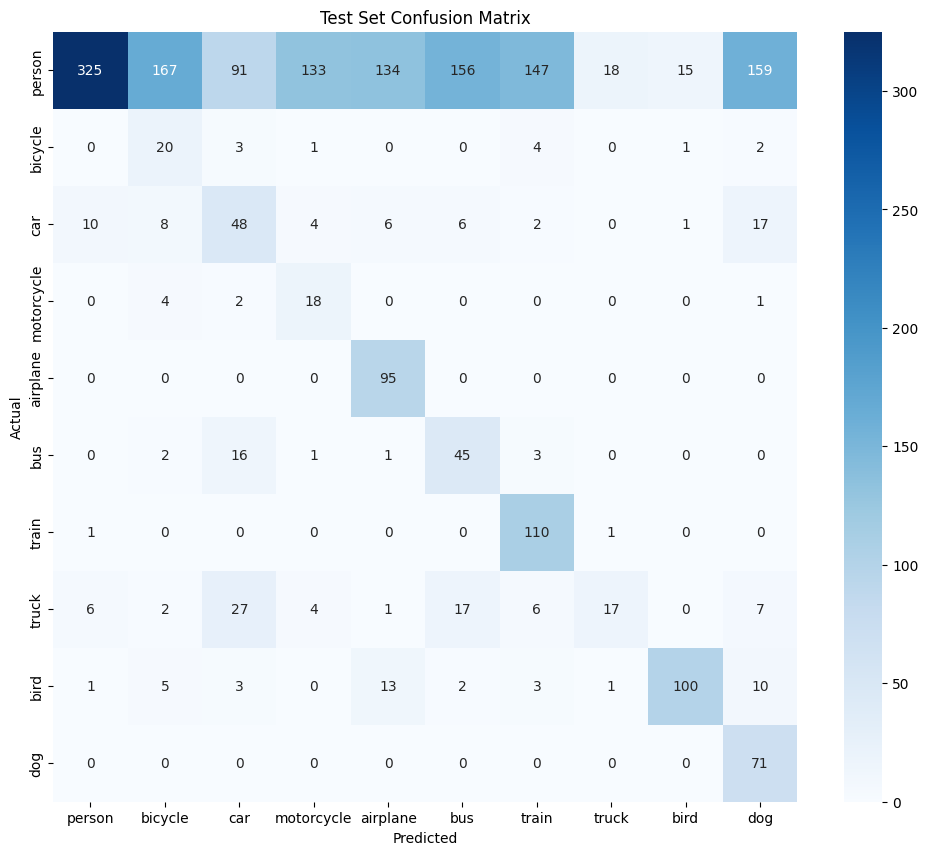

--> K=8 Accuracy: 0.4094

Training with K=16 shots per class...
Epoch 1/20, Loss: 2.2999
Epoch 2/20, Loss: 2.2779
Epoch 3/20, Loss: 2.2584
Epoch 4/20, Loss: 2.2391
Epoch 5/20, Loss: 2.2198
Epoch 6/20, Loss: 2.2007
Epoch 7/20, Loss: 2.1818
Epoch 8/20, Loss: 2.1633
Epoch 9/20, Loss: 2.1444
Epoch 10/20, Loss: 2.1255
Epoch 11/20, Loss: 2.1071
Epoch 12/20, Loss: 2.0885
Epoch 13/20, Loss: 2.0703
Epoch 14/20, Loss: 2.0522
Epoch 15/20, Loss: 2.0344
Epoch 16/20, Loss: 2.0163
Epoch 17/20, Loss: 1.9987
Epoch 18/20, Loss: 1.9810
Epoch 19/20, Loss: 1.9633
Epoch 20/20, Loss: 1.9461


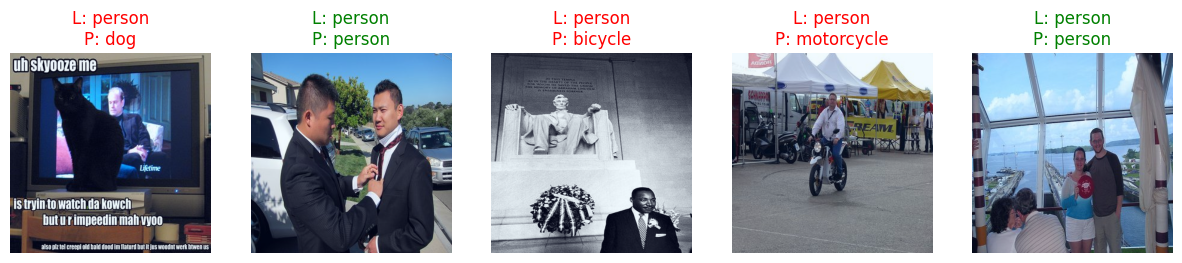

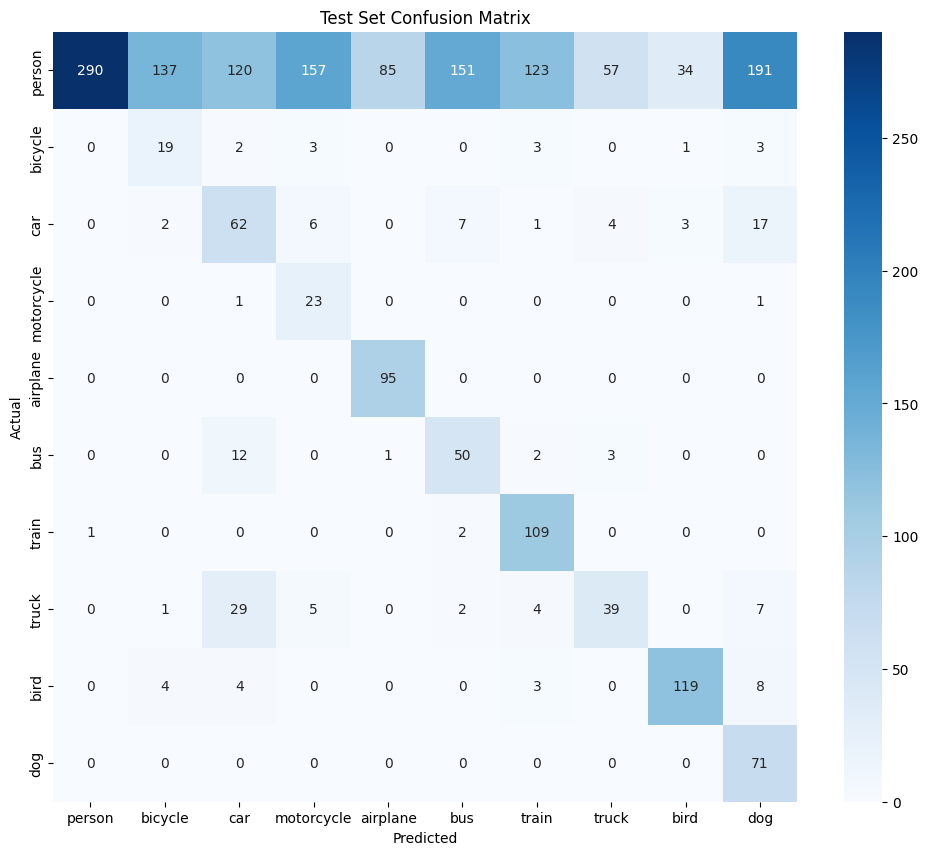

--> K=16 Accuracy: 0.4229


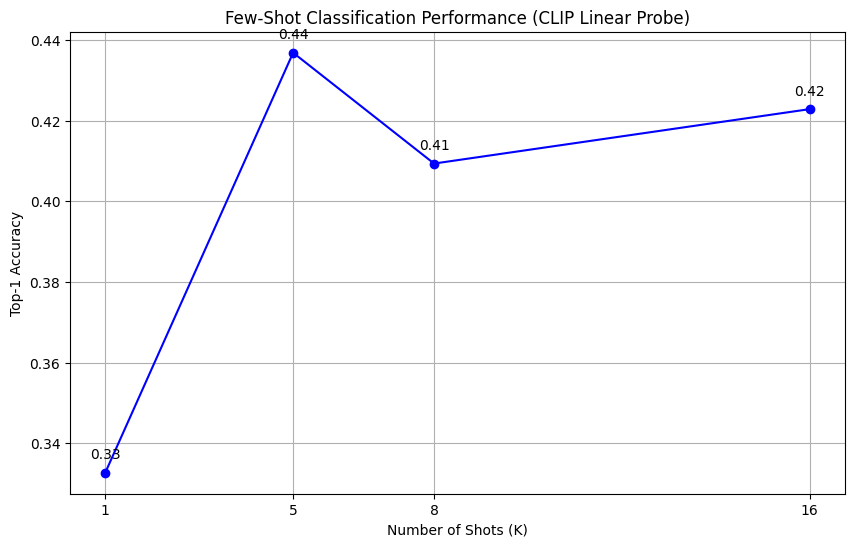

In [10]:
# --- Compare One-Shot vs Few-Shot Performance ---

k_values = [1, 5, 8, 16] # Define K-shots to compare (1 = One-shot)
accuracies = []

print("Evaluating Zero-shot Baseline...")
base_model = CLIPFewShotModel(config['model']['name'], len(config['data']['classes']), device)
report_dict = evaluate_zero_shot(base_model, test_loader, config['data']['classes'], device)

print(f"\n--- Starting Comparison Experiment: K={k_values} ---")

for k in k_values:
    print(f"\nTraining with K={k} shots per class...")

    # Reset Model
    model = reset_model(config)
    optimizer = optim.Adam(model.classifier.parameters(), lr=config['train']['learning_rate'])
    criterion = nn.CrossEntropyLoss()

    # Prepare Data
    few_shot_dataset = create_few_shot_subset(full_train_loader.dataset, k=k, classes=config['data']['classes'])
    few_shot_loader = DataLoader(few_shot_dataset, batch_size=config['data']['batch_size'], shuffle=True)

    # Train
    # Suppress output for loop cleanliness if desired, or keep it
    train_few_shot(model, few_shot_loader, criterion, optimizer, config['train']['epochs'], device)

    # Evaluate
    acc = evaluate_accuracy(model, test_loader, device)
    accuracies.append(acc)
    print(f"--> K={k} Accuracy: {acc:.4f}")

# Plot Results
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b')
plt.title('Few-Shot Classification Performance (CLIP Linear Probe)')
plt.xlabel('Number of Shots (K)')
plt.ylabel('Top-1 Accuracy')
plt.grid(True)
plt.xticks(k_values)
for i, txt in enumerate(accuracies):
    plt.annotate(f"{txt:.2f}", (k_values[i], accuracies[i]), textcoords="offset points", xytext=(0,10), ha='center')
plt.show()